# Round 5 EDA — IMC Prosperity 4

**50 products across 10 groups, 3 days of data (Days 2/3/4), position limit = 10**

## Table of Contents
1. Data Loading & Overview
2. Group-Level Price Trajectories
3. Spread & Liquidity Analysis
4. Mean Reversion vs Trending Analysis
5. Intra-Group Price Relationships
6. PEBBLES Deep Dive — Size Structure & Divergence
7. PANEL Deep Dive — Area vs Price
8. SNACKPACK — Price Hierarchy & Stability
9. Trade Frequency & Volume Analysis
10. Trading Strategy Implications

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['axes.labelcolor'] = '#e0e0e0'
plt.rcParams['text.color'] = '#e0e0e0'
plt.rcParams['xtick.color'] = '#e0e0e0'
plt.rcParams['ytick.color'] = '#e0e0e0'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.color'] = '#2a2a2a'
plt.rcParams['grid.linewidth'] = 0.5

COLORS = ['#00d4ff', '#ff6b6b', '#ffd93d', '#6bcb77', '#ff922b',
          '#cc5de8', '#74c0fc', '#f783ac', '#a9e34b', '#63e6be']
PROD_COLORS = ['#00d4ff','#ff6b6b','#ffd93d','#6bcb77','#cc5de8']

GROUPS = {
    'GALAXY':     ['GALAXY_SOUNDS_DARK_MATTER','GALAXY_SOUNDS_BLACK_HOLES','GALAXY_SOUNDS_PLANETARY_RINGS','GALAXY_SOUNDS_SOLAR_WINDS','GALAXY_SOUNDS_SOLAR_FLAMES'],
    'SLEEP_POD':  ['SLEEP_POD_SUEDE','SLEEP_POD_LAMB_WOOL','SLEEP_POD_POLYESTER','SLEEP_POD_NYLON','SLEEP_POD_COTTON'],
    'MICROCHIP':  ['MICROCHIP_CIRCLE','MICROCHIP_OVAL','MICROCHIP_SQUARE','MICROCHIP_RECTANGLE','MICROCHIP_TRIANGLE'],
    'PEBBLES':    ['PEBBLES_XS','PEBBLES_S','PEBBLES_M','PEBBLES_L','PEBBLES_XL'],
    'ROBOT':      ['ROBOT_VACUUMING','ROBOT_MOPPING','ROBOT_DISHES','ROBOT_LAUNDRY','ROBOT_IRONING'],
    'UV_VISOR':   ['UV_VISOR_YELLOW','UV_VISOR_AMBER','UV_VISOR_ORANGE','UV_VISOR_RED','UV_VISOR_MAGENTA'],
    'TRANSLATOR': ['TRANSLATOR_SPACE_GRAY','TRANSLATOR_ASTRO_BLACK','TRANSLATOR_ECLIPSE_CHARCOAL','TRANSLATOR_GRAPHITE_MIST','TRANSLATOR_VOID_BLUE'],
    'PANEL':      ['PANEL_1X2','PANEL_2X2','PANEL_1X4','PANEL_2X4','PANEL_4X4'],
    'OXYGEN':     ['OXYGEN_SHAKE_MORNING_BREATH','OXYGEN_SHAKE_EVENING_BREATH','OXYGEN_SHAKE_MINT','OXYGEN_SHAKE_CHOCOLATE','OXYGEN_SHAKE_GARLIC'],
    'SNACKPACK':  ['SNACKPACK_CHOCOLATE','SNACKPACK_VANILLA','SNACKPACK_PISTACHIO','SNACKPACK_STRAWBERRY','SNACKPACK_RASPBERRY'],
}
ALL_PRODUCTS = [s for g in GROUPS.values() for s in g]
PROD_GROUP = {s: g for g, ss in GROUPS.items() for s in ss}

DATA_DIR = '../../../data/ROUND_5'   # relative to ying_research/Round_5/pak/

# Load data
price_dfs, trade_dfs = [], []
for d in [2, 3, 4]:
    p = pd.read_csv(f'{DATA_DIR}/prices_round_5_day_{d}.csv', sep=';')
    price_dfs.append(p)
    t = pd.read_csv(f'{DATA_DIR}/trades_round_5_day_{d}.csv', sep=';')
    t['day'] = d; trade_dfs.append(t)

prices = pd.concat(price_dfs, ignore_index=True)
trades = pd.concat(trade_dfs, ignore_index=True)
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']

print(f'Prices: {len(prices):,} rows | Products: {prices["product"].nunique()} | Days: {sorted(prices["day"].unique())}')
print(f'Trades: {len(trades):,} rows | Symbols: {trades["symbol"].nunique()}')

Prices: 1,500,000 rows | Products: 50 | Days: [np.int64(2), np.int64(3), np.int64(4)]
Trades: 35,385 rows | Symbols: 50


## 1. Data Overview

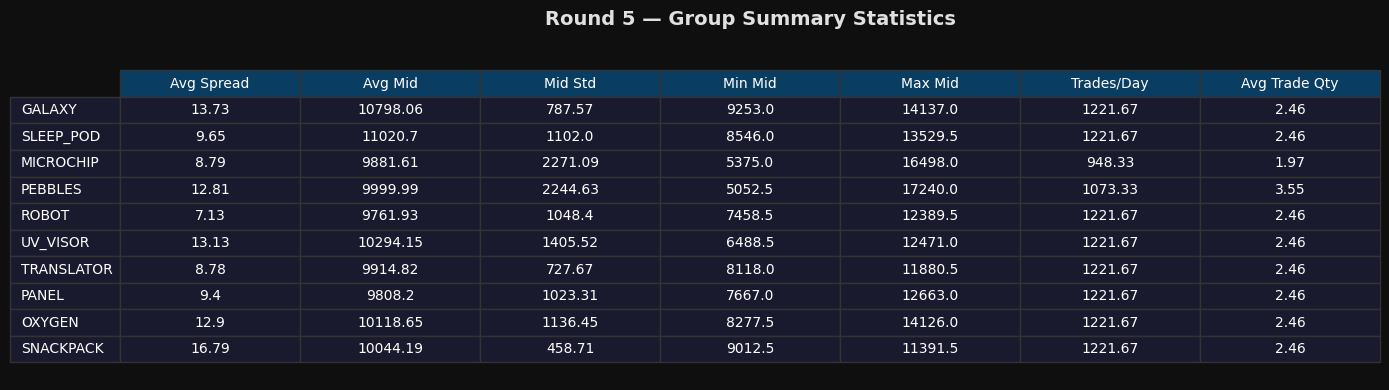

            Avg Spread   Avg Mid  Mid Std  Min Mid  Max Mid  Trades/Day  Avg Trade Qty
Group                                                                                 
GALAXY           13.73  10798.06   787.57   9253.0  14137.0     1221.67           2.46
SLEEP_POD         9.65  11020.70  1102.00   8546.0  13529.5     1221.67           2.46
MICROCHIP         8.79   9881.61  2271.09   5375.0  16498.0      948.33           1.97
PEBBLES          12.81   9999.99  2244.63   5052.5  17240.0     1073.33           3.55
ROBOT             7.13   9761.93  1048.40   7458.5  12389.5     1221.67           2.46
UV_VISOR         13.13  10294.15  1405.52   6488.5  12471.0     1221.67           2.46
TRANSLATOR        8.78   9914.82   727.67   8118.0  11880.5     1221.67           2.46
PANEL             9.40   9808.20  1023.31   7667.0  12663.0     1221.67           2.46
OXYGEN           12.90  10118.65  1136.45   8277.5  14126.0     1221.67           2.46
SNACKPACK        16.79  10044.19   458.71  

In [2]:
# Summary stats per group
rows = []
for grp, prods in GROUPS.items():
    sub = prices[prices['product'].isin(prods)]
    rows.append({
        'Group': grp,
        'Avg Spread': sub['spread'].mean(),
        'Avg Mid': sub['mid_price'].mean(),
        'Mid Std': sub['mid_price'].std(),
        'Min Mid': sub['mid_price'].min(),
        'Max Mid': sub['mid_price'].max(),
        'Trades/Day': len(trades[trades['symbol'].isin(prods)]) / 3,
        'Avg Trade Qty': trades[trades['symbol'].isin(prods)]['quantity'].mean(),
    })
summary = pd.DataFrame(rows).set_index('Group')
summary = summary.round(2)

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
tbl = ax.table(cellText=summary.values,
               colLabels=summary.columns,
               rowLabels=summary.index,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(True)
tbl.scale(1, 1.5)
for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1a2e' if row > 0 else '#0a3d62')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#333')
ax.set_title('Round 5 — Group Summary Statistics', pad=20, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(summary.to_string())

## 2. Group-Level Price Trajectories

Each group's 5 products plotted over 3 days. **Key question: are they trending or mean-reverting?**

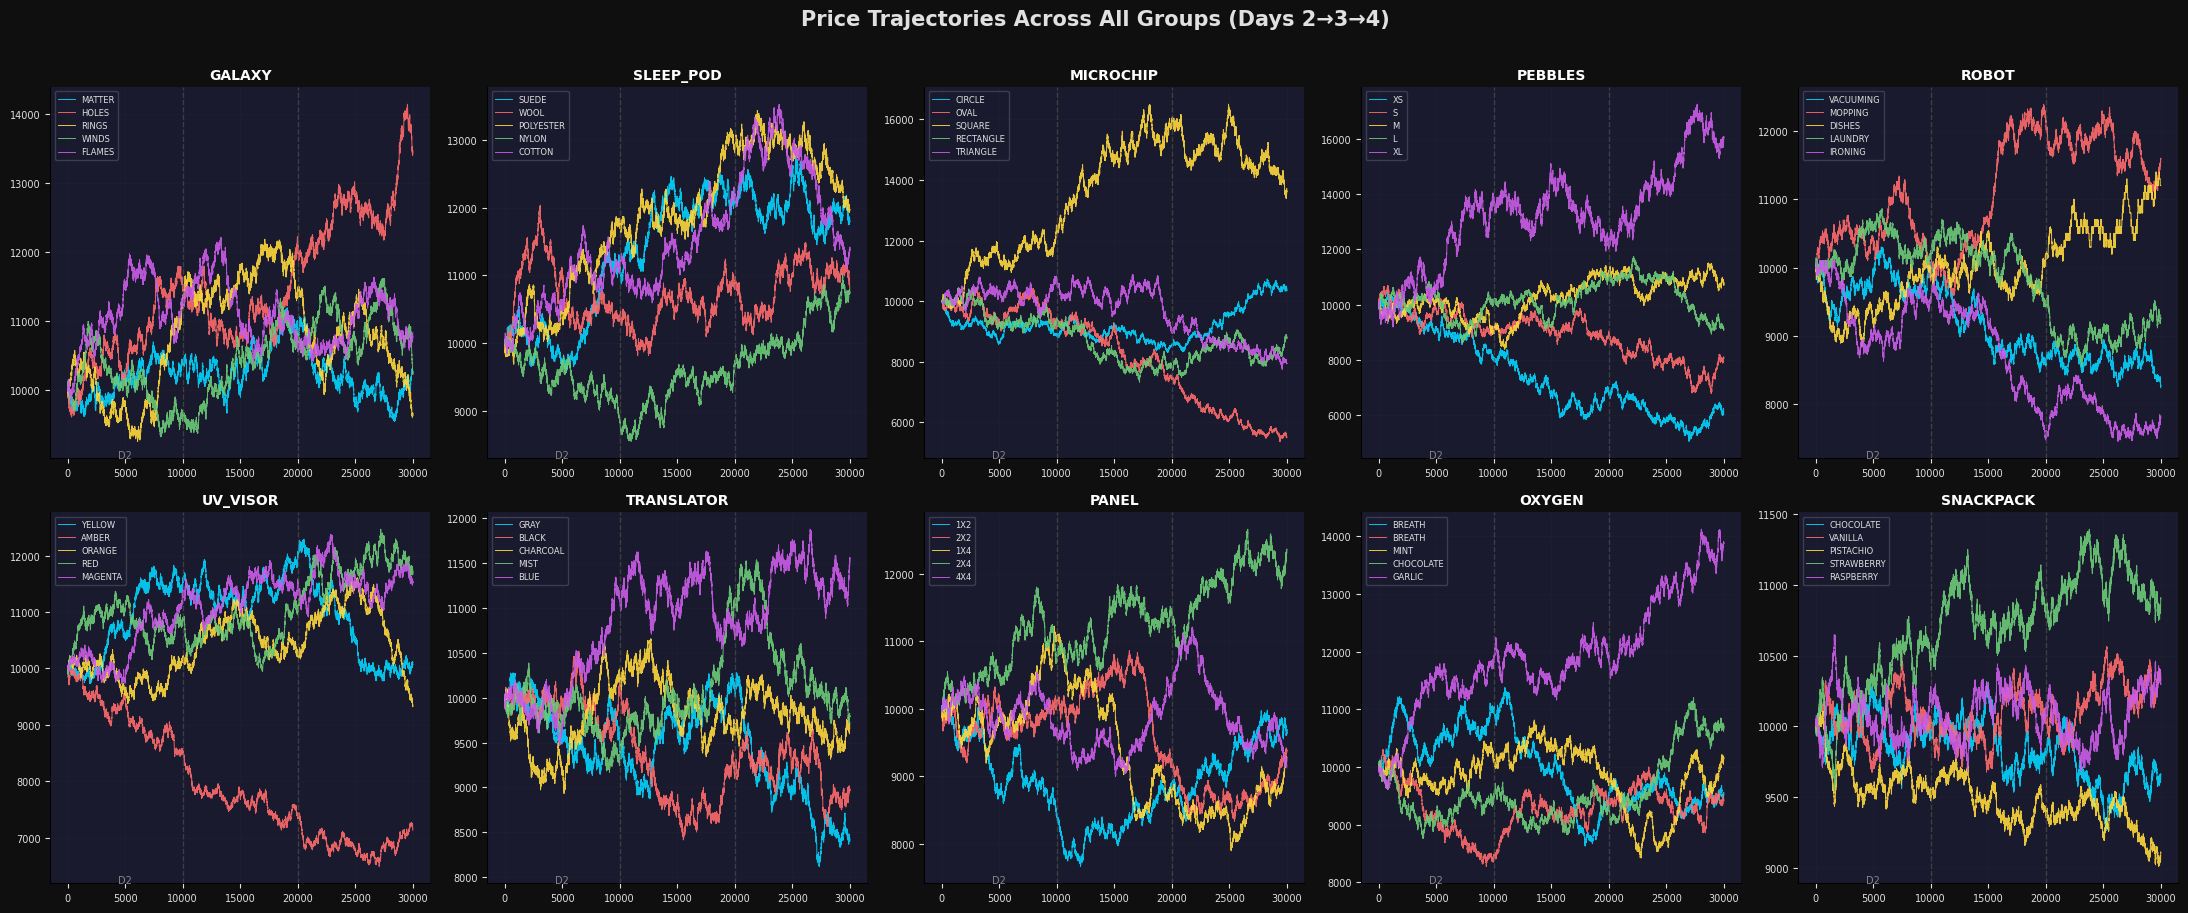

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

# Create a continuous x axis across days
def make_xaxis(sub):
    sub = sub.sort_values(['day', 'timestamp'])
    sub = sub.copy()
    sub['x'] = (sub['day'] - 2) * 10000 + sub['timestamp'] // 100
    return sub

for ax, (grp, prods) in zip(axes, GROUPS.items()):
    for i, prod in enumerate(prods):
        sub = prices[prices['product'] == prod]
        sub = make_xaxis(sub)
        lbl = prod.replace(grp + '_', '').replace(grp.replace('_', ' ') + ' ', '')
        lbl = prod.split('_')[-1] if '_' in prod else prod
        ax.plot(sub['x'], sub['mid_price'], color=PROD_COLORS[i], lw=0.7, label=lbl, alpha=0.9)
    
    # Day dividers
    ax.axvline(10000, color='#555', lw=1, ls='--', alpha=0.6)
    ax.axvline(20000, color='#555', lw=1, ls='--', alpha=0.6)
    ax.text(5000, ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else sub['mid_price'].min()*0.999, 'D2', 
            ha='center', fontsize=7, color='#888')
    
    ax.set_title(grp, fontsize=10, fontweight='bold', color='white')
    ax.legend(fontsize=6, loc='best', framealpha=0.2)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('Price Trajectories Across All Groups (Days 2→3→4)', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Spread & Liquidity Analysis

The bid-ask spread determines how profitable passive market making is. Wider spread = more edge per fill.

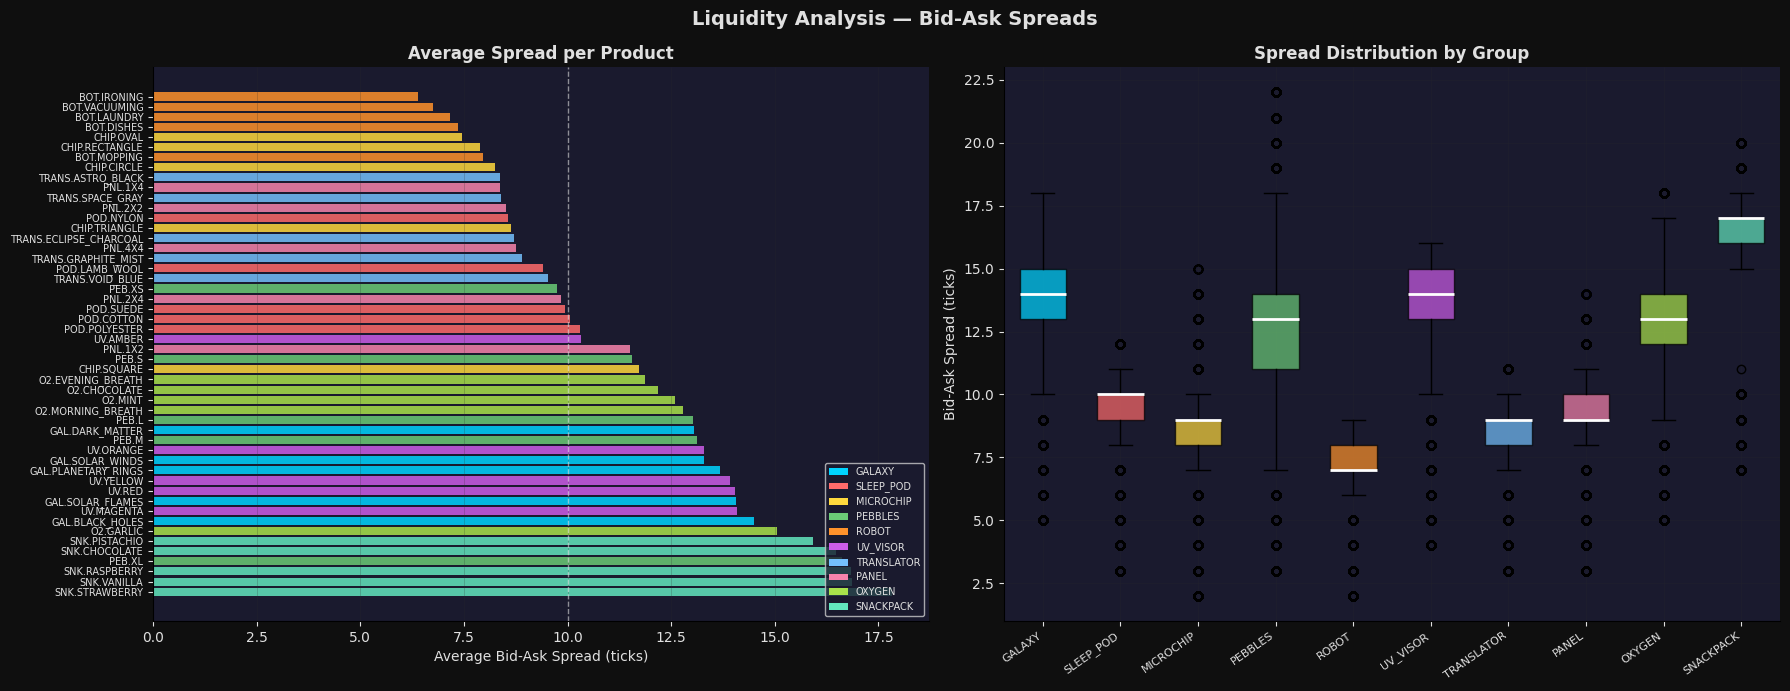


Group spread summary:
  GALAXY      : mean=13.7, median=14.0, std=1.6
  SLEEP_POD   : mean=9.7, median=10.0, std=1.3
  MICROCHIP   : mean=8.8, median=9.0, std=2.0
  PEBBLES     : mean=12.8, median=13.0, std=2.9
  ROBOT       : mean=7.1, median=7.0, std=1.1
  UV_VISOR    : mean=13.1, median=14.0, std=2.1
  TRANSLATOR  : mean=8.8, median=9.0, std=1.1
  PANEL       : mean=9.4, median=9.0, std=1.6
  OXYGEN      : mean=12.9, median=13.0, std=1.8
  SNACKPACK   : mean=16.8, median=17.0, std=1.7


In [4]:
# Per-product spread distribution
spread_stats = prices.groupby('product')['spread'].agg(['mean','std','min','max']).round(2)
spread_stats['group'] = spread_stats.index.map(PROD_GROUP)
spread_stats = spread_stats.sort_values('mean', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: bar chart of average spread per product
grp_colors = {g: COLORS[i] for i, g in enumerate(GROUPS.keys())}
bar_colors = [grp_colors[spread_stats.loc[p, 'group']] for p in spread_stats.index]
bars = ax1.barh(range(len(spread_stats)), spread_stats['mean'], color=bar_colors, alpha=0.85)
ax1.set_yticks(range(len(spread_stats)))
ax1.set_yticklabels([p.replace('GALAXY_SOUNDS_','GAL.').replace('SLEEP_POD_','POD.')
                      .replace('MICROCHIP_','CHIP.').replace('PEBBLES_','PEB.')
                      .replace('ROBOT_','BOT.').replace('UV_VISOR_','UV.')
                      .replace('TRANSLATOR_','TRANS.').replace('PANEL_','PNL.')
                      .replace('OXYGEN_SHAKE_','O2.').replace('SNACKPACK_','SNK.')
                      for p in spread_stats.index], fontsize=7)
ax1.set_xlabel('Average Bid-Ask Spread (ticks)')
ax1.set_title('Average Spread per Product', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.axvline(10, color='white', lw=1, ls='--', alpha=0.5, label='10 ticks')
ax1.legend(fontsize=8)

# Add group legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS[i], label=g) for i, g in enumerate(GROUPS.keys())]
ax1.legend(handles=legend_elements, fontsize=7, loc='lower right')

# Right: group-level spread comparison
grp_spreads = {}
for grp, prods in GROUPS.items():
    grp_spreads[grp] = prices[prices['product'].isin(prods)]['spread'].values

bp = ax2.boxplot([grp_spreads[g] for g in GROUPS.keys()],
                 labels=list(GROUPS.keys()),
                 patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], COLORS[:10]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for elem in ['medians']:
    for line in bp[elem]:
        line.set_color('white'); line.set_linewidth(2)
ax2.set_xticklabels(list(GROUPS.keys()), rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Bid-Ask Spread (ticks)')
ax2.set_title('Spread Distribution by Group', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('Liquidity Analysis — Bid-Ask Spreads', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nGroup spread summary:')
for grp in GROUPS:
    vals = grp_spreads[grp]
    print(f'  {grp:12s}: mean={vals.mean():.1f}, median={np.median(vals):.1f}, std={vals.std():.1f}')

## 4. Mean Reversion vs Trending Analysis

**AC1** (autocorrelation of 1-tick returns): negative = mean-reverting, positive = trending.
**Total drift**: absolute % change over 3 days.

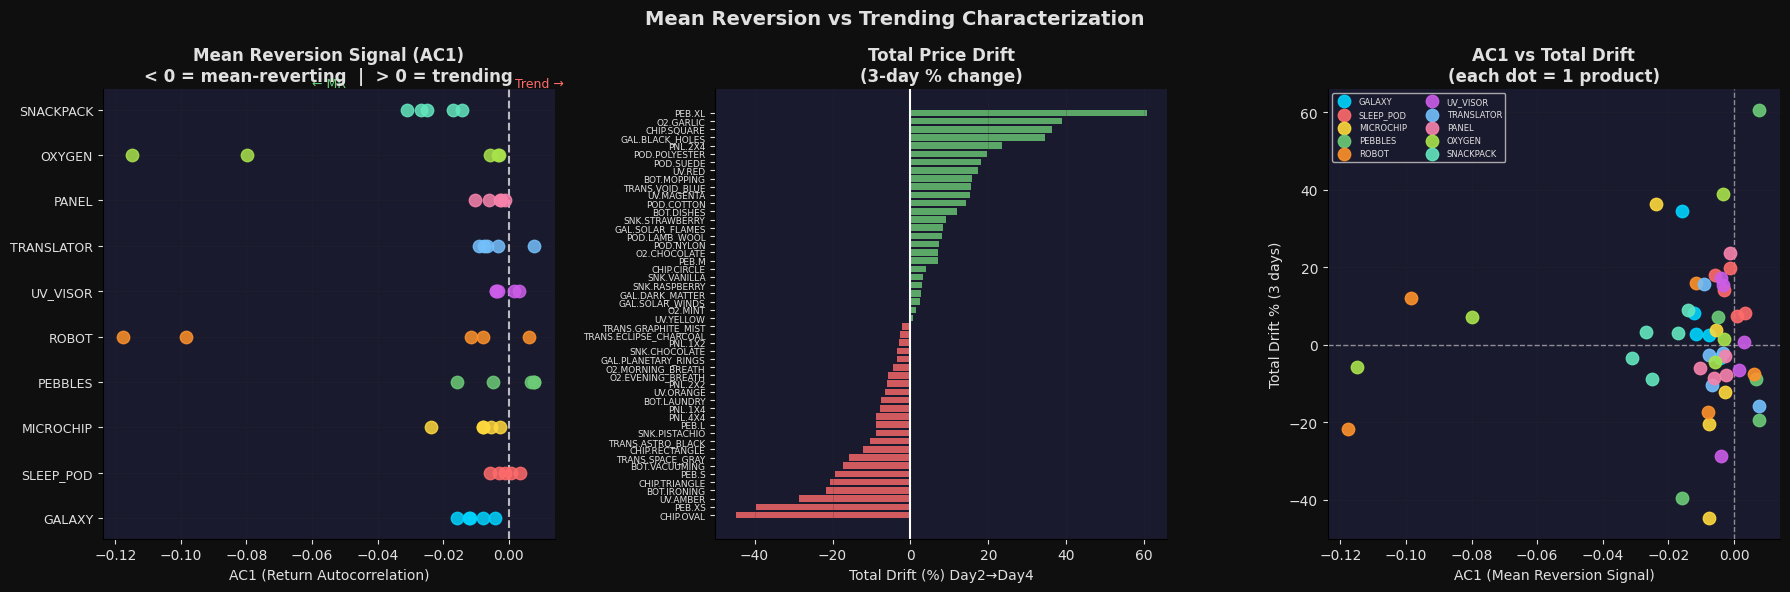


Strongest mean-reverting (AC1 most negative):
                    product  ac1_mean  total_drift_pct
              ROBOT_IRONING -0.117567           -21.70
OXYGEN_SHAKE_EVENING_BREATH -0.114990            -5.80
               ROBOT_DISHES -0.098484            12.00
     OXYGEN_SHAKE_CHOCOLATE -0.079796             7.14
        SNACKPACK_CHOCOLATE -0.031002            -3.38

Strongest trending (largest absolute drift):
                  product  total_drift_pct  ac1_mean
               PEBBLES_XL           60.680  0.007604
           MICROCHIP_OVAL          -44.810 -0.007750
               PEBBLES_XS          -39.620 -0.015700
      OXYGEN_SHAKE_GARLIC           38.860 -0.003300
         MICROCHIP_SQUARE           36.330 -0.023759
GALAXY_SOUNDS_BLACK_HOLES           34.575 -0.015916
           UV_VISOR_AMBER          -28.700 -0.003816
                PANEL_2X4           23.535 -0.001170
            ROBOT_IRONING          -21.700 -0.117567
       MICROCHIP_TRIANGLE          -20.585 -0.0

In [5]:
# Compute AC1 and total drift for each product
product_stats = []
for prod in ALL_PRODUCTS:
    ac1s = []
    for d in [2, 3, 4]:
        sub = prices[(prices['product']==prod) & (prices['day']==d)].sort_values('timestamp')
        ret = sub['mid_price'].diff().dropna().values
        if len(ret) > 2:
            ac1s.append(np.corrcoef(ret[:-1], ret[1:])[0, 1])
    
    start_p = prices[(prices['product']==prod) & (prices['day']==2)]
    start_p = start_p[start_p['timestamp']==0]['mid_price'].values
    end_p = prices[(prices['product']==prod) & (prices['day']==4)]
    max_ts = end_p['timestamp'].max()
    end_p = end_p[end_p['timestamp']==max_ts]['mid_price'].values
    
    drift = (end_p[0] - start_p[0]) / start_p[0] * 100 if len(start_p) > 0 and len(end_p) > 0 else 0
    
    product_stats.append({
        'product': prod,
        'group': PROD_GROUP[prod],
        'ac1_mean': np.mean(ac1s),
        'ac1_std': np.std(ac1s),
        'total_drift_pct': drift,
        'start_price': start_p[0] if len(start_p) > 0 else np.nan,
        'end_price': end_p[0] if len(end_p) > 0 else np.nan,
    })

ps_df = pd.DataFrame(product_stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# AC1 distribution
ax = axes[0]
for i, grp in enumerate(GROUPS.keys()):
    sub = ps_df[ps_df['group']==grp]
    ax.scatter(sub['ac1_mean'], [i]*len(sub), color=COLORS[i], s=80, zorder=3, alpha=0.85)
ax.axvline(0, color='white', lw=1.5, ls='--', alpha=0.7)
ax.set_yticks(range(len(GROUPS)))
ax.set_yticklabels(list(GROUPS.keys()), fontsize=9)
ax.set_xlabel('AC1 (Return Autocorrelation)', fontsize=10)
ax.set_title('Mean Reversion Signal (AC1)\n< 0 = mean-reverting  |  > 0 = trending', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.text(-0.06, 9.5, '← MR', color='#6bcb77', fontsize=9)
ax.text(0.002, 9.5, 'Trend →', color='#ff6b6b', fontsize=9)

# Total drift
ax = axes[1]
ps_sorted = ps_df.sort_values('total_drift_pct')
colors_drift = ['#ff6b6b' if x < 0 else '#6bcb77' for x in ps_sorted['total_drift_pct']]
ax.barh(range(len(ps_sorted)), ps_sorted['total_drift_pct'], color=colors_drift, alpha=0.8)
ax.set_yticks(range(len(ps_sorted)))
ax.set_yticklabels([p.replace('GALAXY_SOUNDS_','GAL.').replace('SLEEP_POD_','POD.')
                     .replace('MICROCHIP_','CHIP.').replace('PEBBLES_','PEB.')
                     .replace('ROBOT_','BOT.').replace('UV_VISOR_','UV.')
                     .replace('TRANSLATOR_','TRANS.').replace('PANEL_','PNL.')
                     .replace('OXYGEN_SHAKE_','O2.').replace('SNACKPACK_','SNK.')
                     for p in ps_sorted['product']], fontsize=6.5)
ax.axvline(0, color='white', lw=1.5)
ax.set_xlabel('Total Drift (%) Day2→Day4')
ax.set_title('Total Price Drift\n(3-day % change)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Scatter: AC1 vs drift
ax = axes[2]
for i, grp in enumerate(GROUPS.keys()):
    sub = ps_df[ps_df['group']==grp]
    ax.scatter(sub['ac1_mean'], sub['total_drift_pct'], color=COLORS[i], 
               s=80, label=grp, zorder=3, alpha=0.9)
ax.axhline(0, color='white', lw=1, ls='--', alpha=0.5)
ax.axvline(0, color='white', lw=1, ls='--', alpha=0.5)
ax.set_xlabel('AC1 (Mean Reversion Signal)')
ax.set_ylabel('Total Drift % (3 days)')
ax.set_title('AC1 vs Total Drift\n(each dot = 1 product)', fontweight='bold')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

plt.suptitle('Mean Reversion vs Trending Characterization', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nStrongest mean-reverting (AC1 most negative):')
print(ps_df.nsmallest(5, 'ac1_mean')[['product','ac1_mean','total_drift_pct']].to_string(index=False))
print('\nStrongest trending (largest absolute drift):')
print(ps_df.reindex(ps_df['total_drift_pct'].abs().nlargest(10).index)[['product','total_drift_pct','ac1_mean']].to_string(index=False))

## 5. Intra-Group Price Relationships

Do products within the same group move together, independently, or diverge? This tells us whether the group shares a common underlying price process.

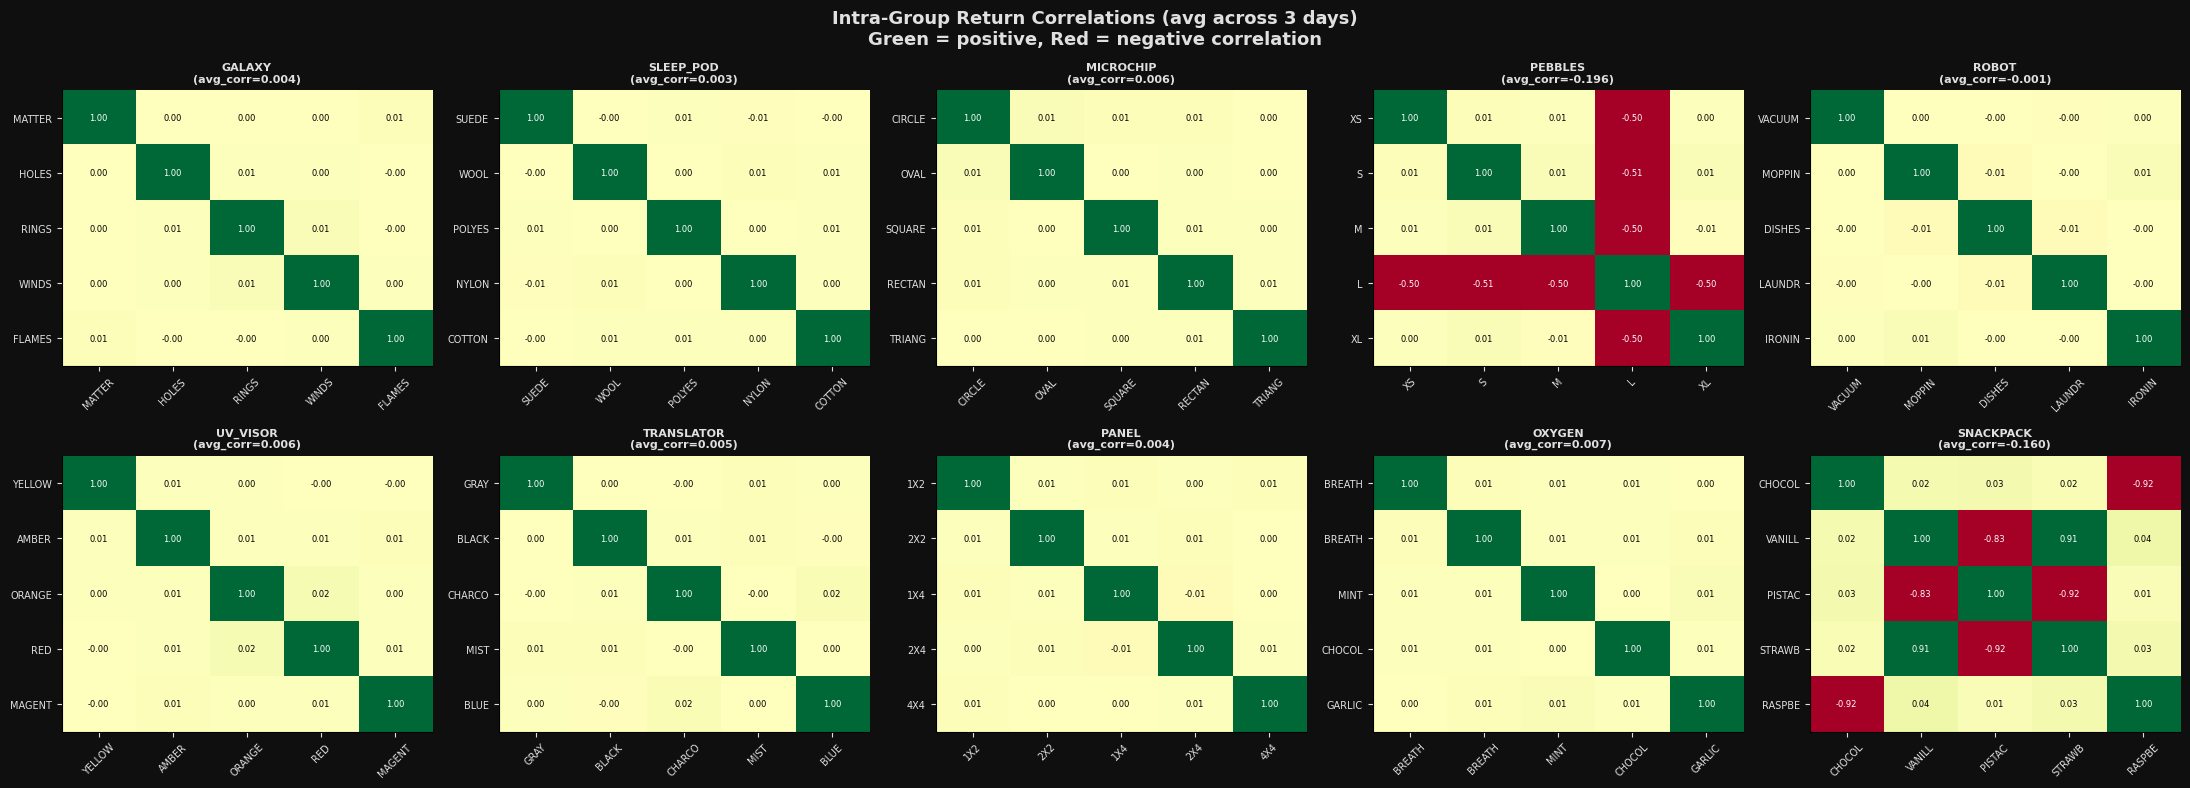


Average off-diagonal return correlation by group (>0 = products move together):
  OXYGEN      : +0.0071  → independent
  MICROCHIP   : +0.0062  → independent
  UV_VISOR    : +0.0060  → independent
  TRANSLATOR  : +0.0045  → independent
  PANEL       : +0.0044  → independent
  GALAXY      : +0.0040  → independent
  SLEEP_POD   : +0.0027  → independent
  ROBOT       : -0.0012  → independent
  SNACKPACK   : -0.1600  → NEGATIVE corr!
  PEBBLES     : -0.1961  → NEGATIVE corr!


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

group_corr_summary = {}

for ax, (grp, prods) in zip(axes, GROUPS.items()):
    # Compute pairwise correlation of mid prices across all days
    corr_mats = []
    for d in [2, 3, 4]:
        sub = prices[prices['day']==d]
        pivot = sub[sub['product'].isin(prods)].pivot_table(
            index='timestamp', columns='product', values='mid_price')
        # Correlation of RETURNS (not levels) to remove trend artifact
        ret = pivot.diff().dropna()
        if len(ret) > 10:
            corr_mats.append(ret.corr().values)
    
    avg_corr = np.mean(corr_mats, axis=0)
    group_corr_summary[grp] = np.mean(avg_corr[np.triu_indices(5, 1)])
    
    short_names = [p.split('_')[-1][:6] for p in prods]
    im = ax.imshow(avg_corr, cmap='RdYlGn', vmin=-0.5, vmax=0.5, aspect='auto')
    ax.set_xticks(range(5)); ax.set_xticklabels(short_names, rotation=45, fontsize=7)
    ax.set_yticks(range(5)); ax.set_yticklabels(short_names, fontsize=7)
    ax.set_title(f'{grp}\n(avg_corr={group_corr_summary[grp]:.3f})', fontsize=8, fontweight='bold')
    
    # Annotate with values
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{avg_corr[i,j]:.2f}', ha='center', va='center',
                    fontsize=6, color='black' if abs(avg_corr[i,j]) < 0.3 else 'white')

plt.suptitle('Intra-Group Return Correlations (avg across 3 days)\nGreen = positive, Red = negative correlation',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nAverage off-diagonal return correlation by group (>0 = products move together):')
for g, c in sorted(group_corr_summary.items(), key=lambda x: -x[1]):
    interpretation = '→ shared driver' if c > 0.2 else ('→ independent' if c > -0.1 else '→ NEGATIVE corr!')
    print(f'  {g:12s}: {c:+.4f}  {interpretation}')

## 6. PEBBLES Deep Dive — Size Structure & Divergence

PEBBLES has a size ordering (XS→XL). Are prices proportional to size? Can we exploit price convexity?

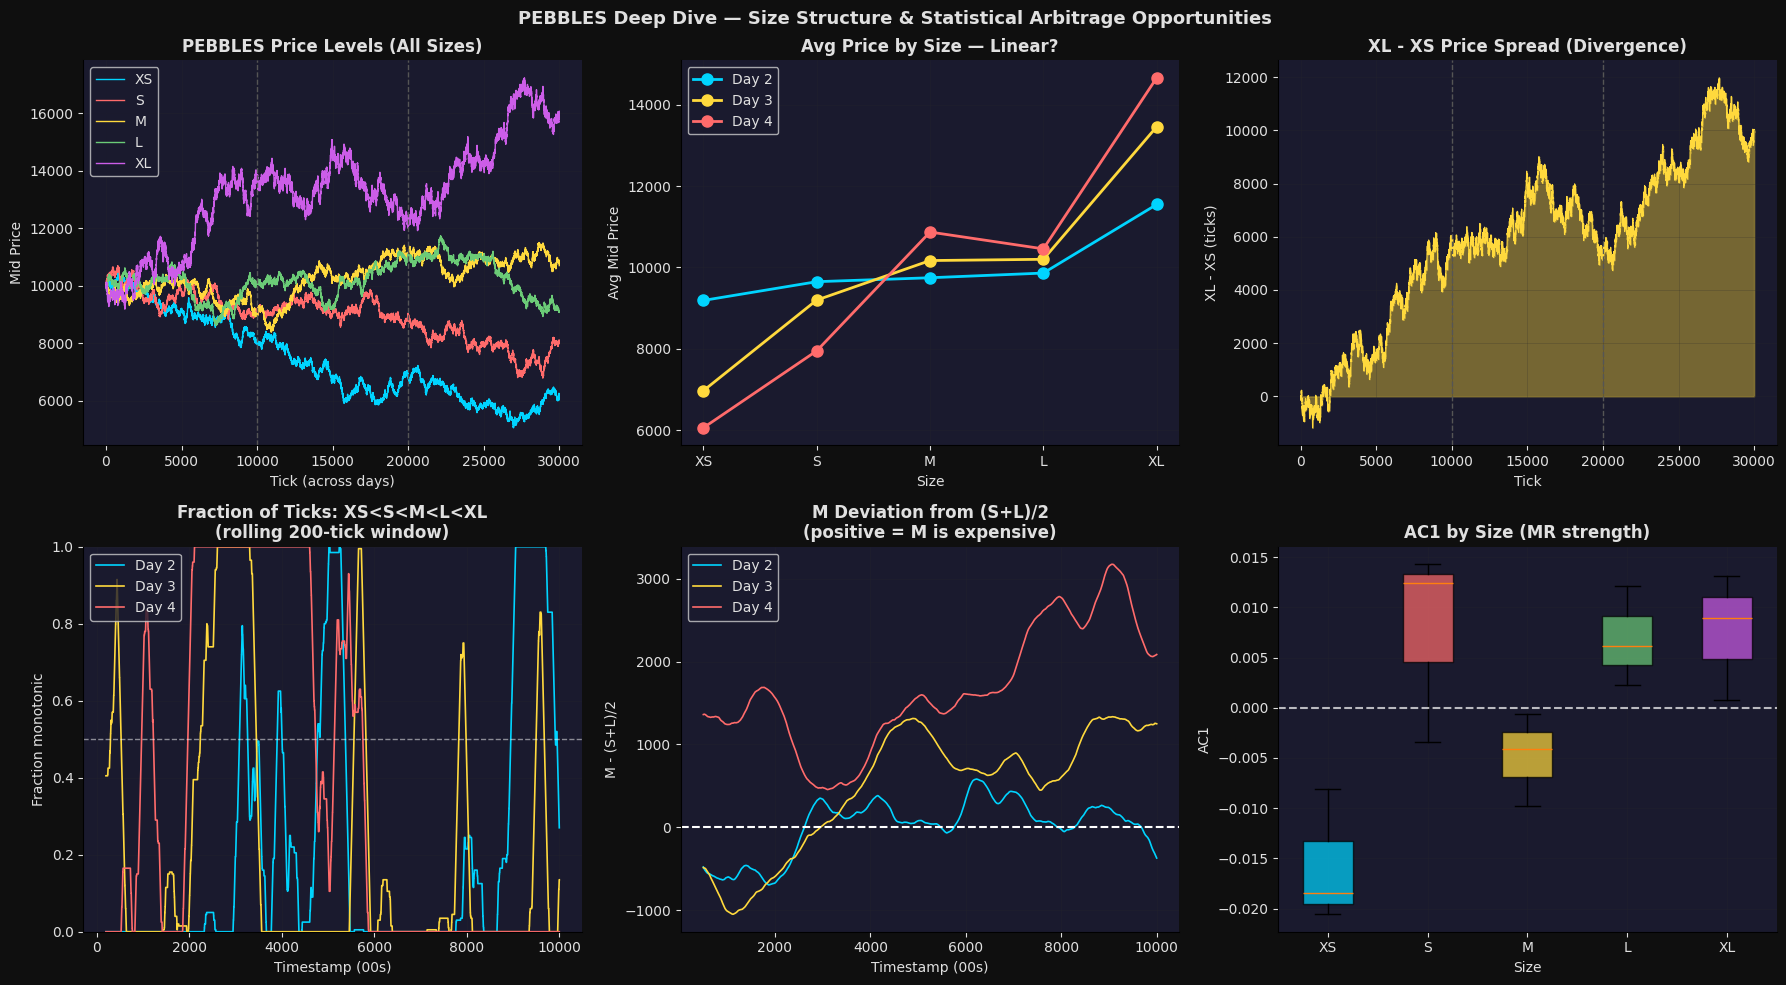

PEBBLES key findings:
• XL-XS spread grows dramatically across days (D2: ~2360, D3: ~6494, D4: ~8609)
• Size ordering XS<S<M<L<XL holds only 21-36% of ticks → massive mispricing windows
• M deviates from (S+L)/2 mean → potential convexity arb


In [7]:
pebble_order = ['PEBBLES_XS', 'PEBBLES_S', 'PEBBLES_M', 'PEBBLES_L', 'PEBBLES_XL']
pebble_short = ['XS', 'S', 'M', 'L', 'XL']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Price levels per pebble over time (all 3 days)
ax = axes[0, 0]
for i, (prod, short) in enumerate(zip(pebble_order, pebble_short)):
    sub = prices[prices['product']==prod].sort_values(['day','timestamp'])
    sub = sub.copy(); sub['x'] = (sub['day']-2)*10000 + sub['timestamp']//100
    ax.plot(sub['x'], sub['mid_price'], color=PROD_COLORS[i], lw=1, label=short)
ax.axvline(10000, color='#555', lw=1, ls='--'); ax.axvline(20000, color='#555', lw=1, ls='--')
ax.set_title('PEBBLES Price Levels (All Sizes)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlabel('Tick (across days)')
ax.set_ylabel('Mid Price')

# 2. Price by size — do they scale linearly?
ax = axes[0, 1]
size_idx = [1, 2, 3, 4, 5]  # XS=1, S=2, M=3, L=4, XL=5
for d, col in zip([2, 3, 4], ['#00d4ff', '#ffd93d', '#ff6b6b']):
    day_means = []
    for prod in pebble_order:
        sub = prices[(prices['product']==prod) & (prices['day']==d)]
        day_means.append(sub['mid_price'].mean())
    ax.plot(size_idx, day_means, 'o-', color=col, lw=2, label=f'Day {d}', ms=8)
ax.set_xticks(size_idx); ax.set_xticklabels(pebble_short)
ax.set_title('Avg Price by Size — Linear?', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlabel('Size'); ax.set_ylabel('Avg Mid Price')

# 3. XL-XS spread over time (divergence signal)
ax = axes[0, 2]
xl = prices[prices['product']=='PEBBLES_XL'].sort_values(['day','timestamp']).reset_index(drop=True)
xs = prices[prices['product']=='PEBBLES_XS'].sort_values(['day','timestamp']).reset_index(drop=True)
xl['x'] = (xl['day']-2)*10000 + xl['timestamp']//100
spread_xl_xs = xl.set_index('x')['mid_price'] - xs.set_index(xl['x'])['mid_price']
ax.fill_between(xl['x'], xl['mid_price'] - xs.set_index(xl['x'])['mid_price'].values,
                alpha=0.4, color='#ffd93d')
ax.plot(xl['x'], xl['mid_price'] - xs.set_index(xl['x'])['mid_price'].values, color='#ffd93d', lw=0.8)
ax.axvline(10000, color='#555', lw=1, ls='--'); ax.axvline(20000, color='#555', lw=1, ls='--')
ax.set_title('XL - XS Price Spread (Divergence)', fontweight='bold')
ax.grid(True, alpha=0.3); ax.set_xlabel('Tick'); ax.set_ylabel('XL - XS (ticks)')

# 4. Monotonicity check per tick
ax = axes[1, 0]
for d, col in zip([2, 3, 4], ['#00d4ff', '#ffd93d', '#ff6b6b']):
    sub = prices[prices['day']==d]
    pivot = sub[sub['product'].isin(pebble_order)].pivot_table(
        index='timestamp', columns='product', values='mid_price')[pebble_order]
    mono_rolling = (pivot.diff(axis=1).iloc[:,1:] > 0).all(axis=1).rolling(200).mean()
    ax.plot(pivot.index//100, mono_rolling, color=col, lw=1.2, label=f'Day {d}')
ax.set_title('Fraction of Ticks: XS<S<M<L<XL\n(rolling 200-tick window)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1)
ax.axhline(0.5, color='white', lw=1, ls='--', alpha=0.5)
ax.set_xlabel('Timestamp (00s)'); ax.set_ylabel('Fraction monotonic')

# 5. Convexity: is M price between S and L?
ax = axes[1, 1]
for d, col in zip([2, 3, 4], ['#00d4ff', '#ffd93d', '#ff6b6b']):
    sub = prices[prices['day']==d]
    pivot = sub[sub['product'].isin(pebble_order)].pivot_table(
        index='timestamp', columns='product', values='mid_price')[pebble_order]
    # How much does M deviate from the (S+L)/2 midpoint?
    mid_theory = (pivot['PEBBLES_S'] + pivot['PEBBLES_L']) / 2
    deviation = pivot['PEBBLES_M'] - mid_theory
    ax.plot(pivot.index//100, deviation.rolling(500).mean(), color=col, lw=1.2, label=f'Day {d}')
ax.axhline(0, color='white', lw=1.5, ls='--')
ax.set_title('M Deviation from (S+L)/2\n(positive = M is expensive)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlabel('Timestamp (00s)'); ax.set_ylabel('M - (S+L)/2')

# 6. AC1 per pebble
ax = axes[1, 2]
peb_ac1 = {}
for prod, short in zip(pebble_order, pebble_short):
    ac1s = []
    for d in [2,3,4]:
        sub = prices[(prices['product']==prod)&(prices['day']==d)].sort_values('timestamp')
        ret = sub['mid_price'].diff().dropna().values
        if len(ret) > 2: ac1s.append(np.corrcoef(ret[:-1],ret[1:])[0,1])
    peb_ac1[short] = ac1s

bp = ax.boxplot([peb_ac1[s] for s in pebble_short], labels=pebble_short,
                patch_artist=True, widths=0.5)
for patch, col in zip(bp['boxes'], PROD_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax.axhline(0, color='white', lw=1.5, ls='--', alpha=0.7)
ax.set_title('AC1 by Size (MR strength)', fontweight='bold')
ax.set_xlabel('Size'); ax.set_ylabel('AC1')
ax.grid(True, alpha=0.3)

plt.suptitle('PEBBLES Deep Dive — Size Structure & Statistical Arbitrage Opportunities',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('PEBBLES key findings:')
print('• XL-XS spread grows dramatically across days (D2: ~2360, D3: ~6494, D4: ~8609)')
print('• Size ordering XS<S<M<L<XL holds only 21-36% of ticks → massive mispricing windows')
print('• M deviates from (S+L)/2 mean → potential convexity arb')

## 7. PANEL Deep Dive — Area vs Price Relationship

Panels have different dimensions: 1×2, 2×2, 1×4, 2×4, 4×4. If price ∝ area, we can identify mispriced panels.

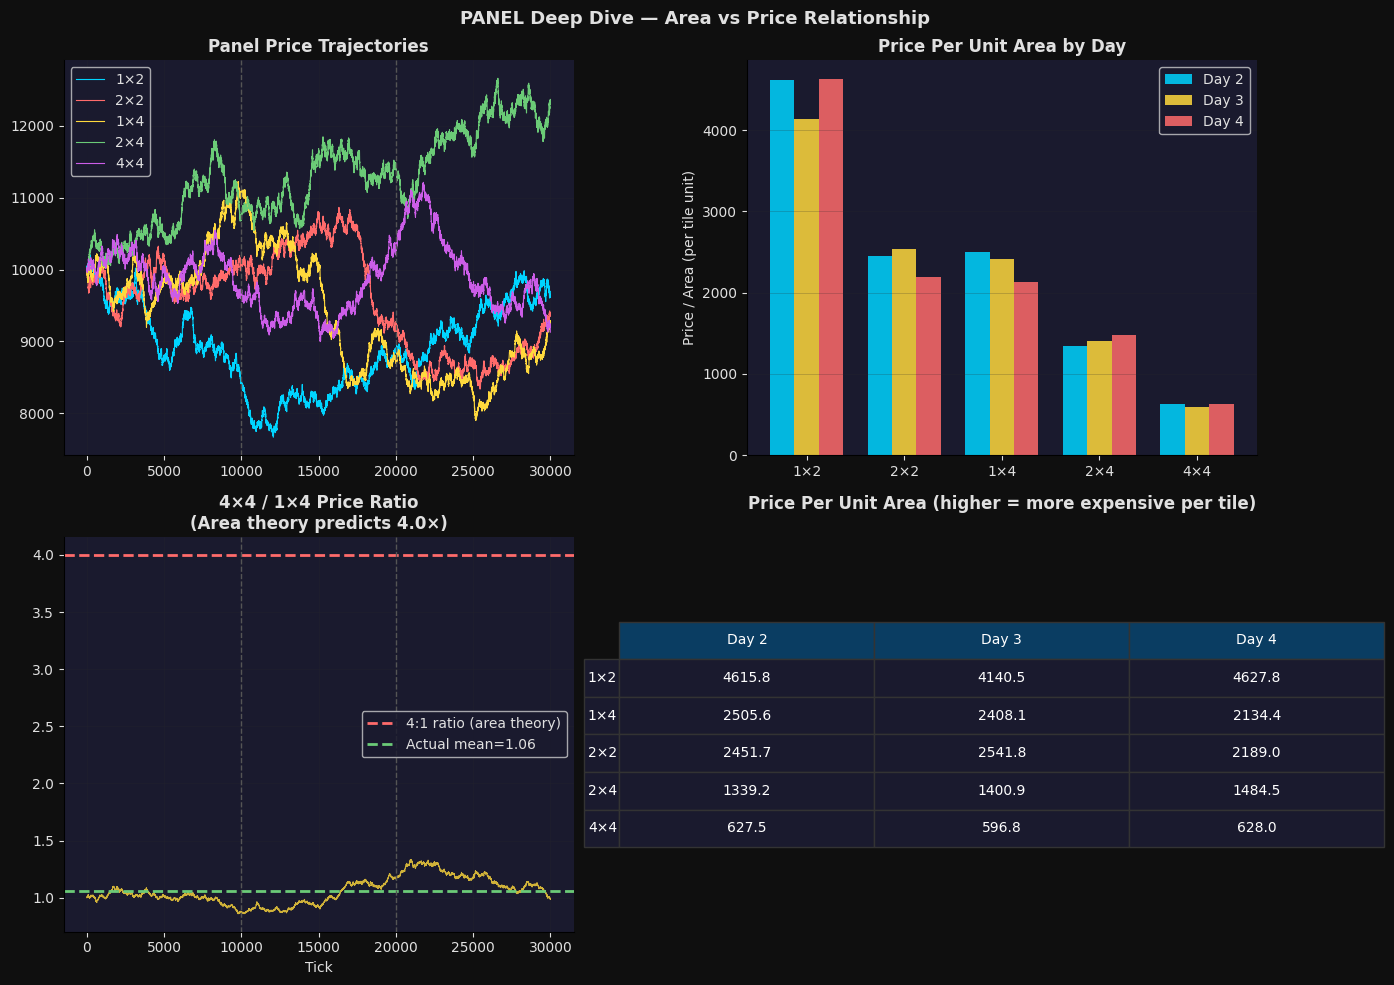

PANEL key findings:
• Price per unit area NOT constant → smaller panels are much more expensive per tile
• 1×2: ~4600/area vs 4×4: ~627/area → bulk discount of 7×
• No simple arbitrage (buying many 1×2 to make a 4×4 is not equivalent)


In [8]:
panel_prods = ['PANEL_1X2', 'PANEL_2X2', 'PANEL_1X4', 'PANEL_2X4', 'PANEL_4X4']
panel_areas = {'PANEL_1X2': 2, 'PANEL_2X2': 4, 'PANEL_1X4': 4, 'PANEL_2X4': 8, 'PANEL_4X4': 16}
panel_short = {'PANEL_1X2': '1×2', 'PANEL_2X2': '2×2', 'PANEL_1X4': '1×4', 'PANEL_2X4': '2×4', 'PANEL_4X4': '4×4'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Price trajectories
ax = axes[0, 0]
for i, prod in enumerate(panel_prods):
    sub = prices[prices['product']==prod].sort_values(['day','timestamp'])
    sub = sub.copy(); sub['x'] = (sub['day']-2)*10000 + sub['timestamp']//100
    ax.plot(sub['x'], sub['mid_price'], color=PROD_COLORS[i], lw=0.8, label=panel_short[prod])
ax.axvline(10000, color='#555', lw=1, ls='--'); ax.axvline(20000, color='#555', lw=1, ls='--')
ax.set_title('Panel Price Trajectories', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# 2. Price per unit area
ax = axes[0, 1]
for d, col in zip([2, 3, 4], ['#00d4ff', '#ffd93d', '#ff6b6b']):
    price_per_area = []
    for prod in panel_prods:
        mean_p = prices[(prices['product']==prod)&(prices['day']==d)]['mid_price'].mean()
        price_per_area.append(mean_p / panel_areas[prod])
    ax.bar([x + [-.25, 0, .25].index(x-int(x)) if False else i + (d-3)*0.25 
            for i in range(5) for _ in [None]][::5],  
           price_per_area, width=0.25, color=col, label=f'Day {d}', alpha=0.8)
# Simpler version:
ax.cla()
x = np.arange(5); w = 0.25
for i, (d, col) in enumerate(zip([2,3,4], ['#00d4ff','#ffd93d','#ff6b6b'])):
    vals = [prices[(prices['product']==p)&(prices['day']==d)]['mid_price'].mean()/panel_areas[p] for p in panel_prods]
    ax.bar(x + (i-1)*w, vals, width=w, color=col, label=f'Day {d}', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([panel_short[p] for p in panel_prods])
ax.set_title('Price Per Unit Area by Day', fontweight='bold')
ax.set_ylabel('Price / Area (per tile unit)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor('#1a1a2e')

# 3. 4X4 vs others (is it priced as 4× 1×4?)
ax = axes[1, 0]
p4x4 = prices[prices['product']=='PANEL_4X4'].sort_values(['day','timestamp']).reset_index(drop=True)
p1x4 = prices[prices['product']=='PANEL_1X4'].sort_values(['day','timestamp']).reset_index(drop=True)
p4x4['x'] = (p4x4['day']-2)*10000 + p4x4['timestamp']//100
ratio = p4x4['mid_price'].values / p1x4['mid_price'].values[:len(p4x4)]
ax.plot(p4x4['x'], ratio, color='#ffd93d', lw=0.7, alpha=0.8)
ax.axhline(4.0, color='#ff6b6b', lw=2, ls='--', label='4:1 ratio (area theory)')
ax.axhline(np.mean(ratio), color='#6bcb77', lw=2, ls='--', label=f'Actual mean={np.mean(ratio):.2f}')
ax.axvline(10000, color='#555', lw=1, ls='--'); ax.axvline(20000, color='#555', lw=1, ls='--')
ax.set_title('4×4 / 1×4 Price Ratio\n(Area theory predicts 4.0×)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlabel('Tick')

# 4. Summary of per-area pricing
ax = axes[1, 1]
rows_p = []
for prod in panel_prods:
    for d in [2,3,4]:
        mean_p = prices[(prices['product']==prod)&(prices['day']==d)]['mid_price'].mean()
        rows_p.append({'Product': panel_short[prod], 'Day': d, 'Area': panel_areas[prod],
                        'Avg Price': mean_p, 'Per Area': mean_p/panel_areas[prod]})
pnl_df = pd.DataFrame(rows_p)
pivot_area = pnl_df.pivot_table(index='Product', columns='Day', values='Per Area').round(1)
ax.axis('off')
tbl = ax.table(cellText=pivot_area.values,
               colLabels=[f'Day {d}' for d in [2,3,4]],
               rowLabels=pivot_area.index,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(True); tbl.scale(1.5, 2)
for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1a2e' if row > 0 else '#0a3d62')
    cell.set_text_props(color='white'); cell.set_edgecolor('#333')
ax.set_title('Price Per Unit Area (higher = more expensive per tile)', fontweight='bold', pad=20)

plt.suptitle('PANEL Deep Dive — Area vs Price Relationship', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('PANEL key findings:')
print('• Price per unit area NOT constant → smaller panels are much more expensive per tile')
print('• 1×2: ~4600/area vs 4×4: ~627/area → bulk discount of 7×')
print('• No simple arbitrage (buying many 1×2 to make a 4×4 is not equivalent)')

## 8. SNACKPACK — Price Hierarchy & Stability

Snackpacks have the widest spread (16.8 ticks avg). Are some consistently more valuable than others?

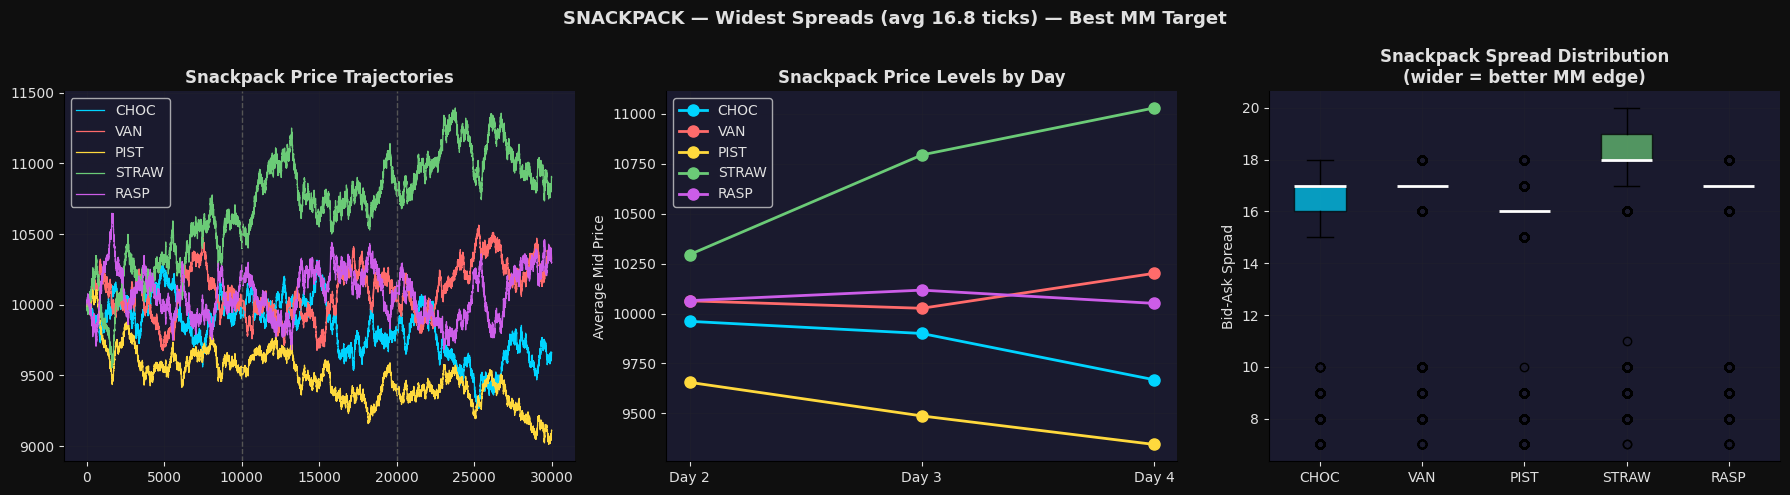

SNACKPACK key findings:
• Widest spread of all groups (avg 16.8) → each fill earns ~8 ticks
• STRAWBERRY consistently most expensive (+$1000 above others)
• PISTACHIO consistently cheapest (trending down)
• All prices diverge over time → significant intra-group dispersion


In [9]:
snack_prods = ['SNACKPACK_CHOCOLATE','SNACKPACK_VANILLA','SNACKPACK_PISTACHIO','SNACKPACK_STRAWBERRY','SNACKPACK_RASPBERRY']
snack_short = ['CHOC','VAN','PIST','STRAW','RASP']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Trajectories
ax = axes[0]
for i, (prod, short) in enumerate(zip(snack_prods, snack_short)):
    sub = prices[prices['product']==prod].sort_values(['day','timestamp'])
    sub = sub.copy(); sub['x'] = (sub['day']-2)*10000 + sub['timestamp']//100
    ax.plot(sub['x'], sub['mid_price'], color=PROD_COLORS[i], lw=0.9, label=short)
ax.axvline(10000, color='#555', lw=1, ls='--'); ax.axvline(20000, color='#555', lw=1, ls='--')
ax.set_title('Snackpack Price Trajectories', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# 2. Price hierarchy (violin plots per day)
ax = axes[1]
day_data = []
for d in [2,3,4]:
    sub = prices[prices['day']==d]
    for prod, short in zip(snack_prods, snack_short):
        day_data.append({'short': short, 'day': d,
                         'mean': sub[sub['product']==prod]['mid_price'].mean()})
dd = pd.DataFrame(day_data)
pivot_snack = dd.pivot(index='short', columns='day', values='mean')
for i, short in enumerate(snack_short):
    row = pivot_snack.loc[short]
    ax.plot([2,3,4], row.values, 'o-', color=PROD_COLORS[i], lw=2, ms=8, label=short)
ax.set_xticks([2,3,4]); ax.set_xticklabels(['Day 2','Day 3','Day 4'])
ax.set_title('Snackpack Price Levels by Day', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylabel('Average Mid Price')

# 3. Spread stability
ax = axes[2]
snack_spreads = {}
for prod, short in zip(snack_prods, snack_short):
    snack_spreads[short] = prices[prices['product']==prod]['spread'].values
bp = ax.boxplot([snack_spreads[s] for s in snack_short], labels=snack_short,
                patch_artist=True, widths=0.5)
for patch, col in zip(bp['boxes'], PROD_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.7)
for elem in ['medians']:
    for line in bp[elem]: line.set_color('white'); line.set_linewidth(2)
ax.set_title('Snackpack Spread Distribution\n(wider = better MM edge)', fontweight='bold')
ax.set_ylabel('Bid-Ask Spread'); ax.grid(True, alpha=0.3)

plt.suptitle('SNACKPACK — Widest Spreads (avg 16.8 ticks) — Best MM Target', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('SNACKPACK key findings:')
print('• Widest spread of all groups (avg 16.8) → each fill earns ~8 ticks')
print('• STRAWBERRY consistently most expensive (+$1000 above others)')
print('• PISTACHIO consistently cheapest (trending down)')
print('• All prices diverge over time → significant intra-group dispersion')

## 9. Trade Frequency & Volume Analysis

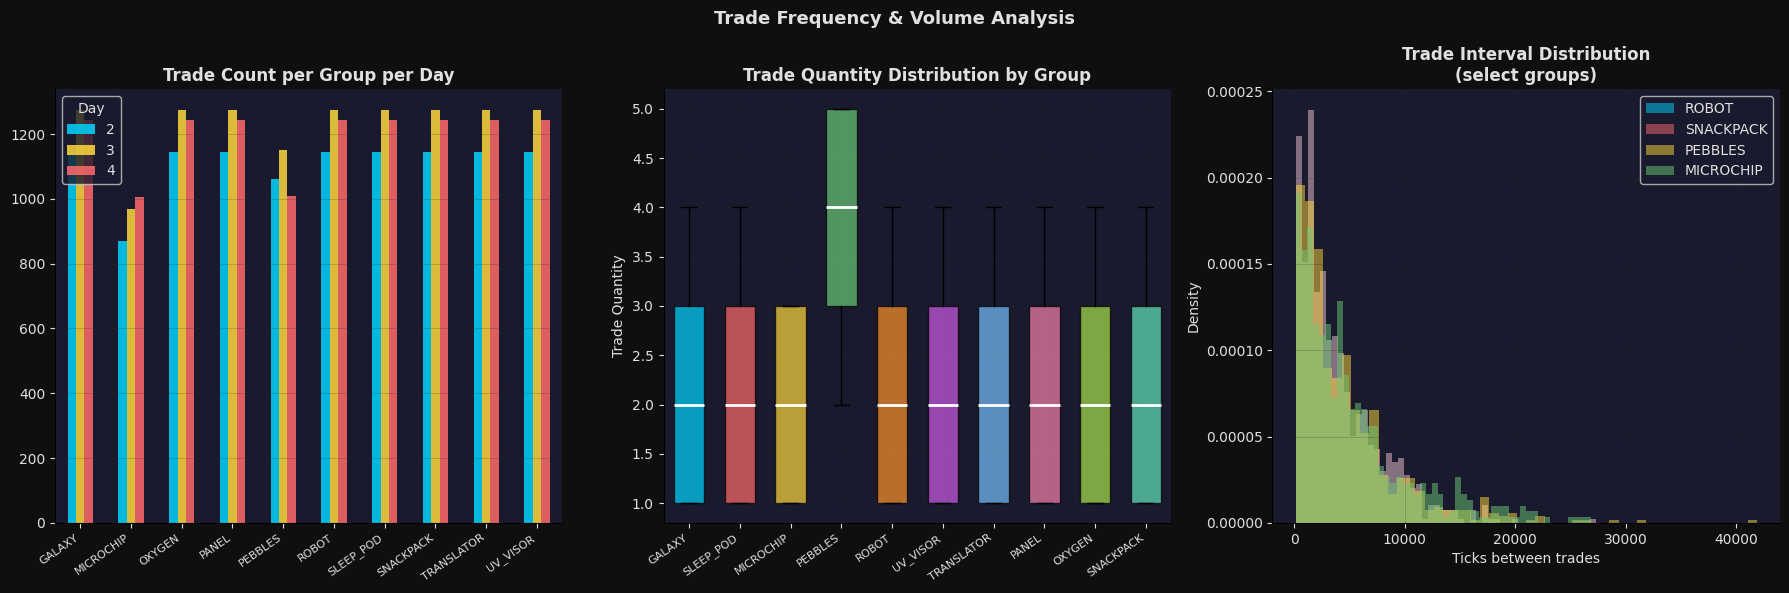


Trade statistics by group:
  GALAXY      :   1222 trades/day, avg qty=2.5, max qty=4
  SLEEP_POD   :   1222 trades/day, avg qty=2.5, max qty=4
  MICROCHIP   :    948 trades/day, avg qty=2.0, max qty=3
  PEBBLES     :   1073 trades/day, avg qty=3.5, max qty=5
  ROBOT       :   1222 trades/day, avg qty=2.5, max qty=4
  UV_VISOR    :   1222 trades/day, avg qty=2.5, max qty=4
  TRANSLATOR  :   1222 trades/day, avg qty=2.5, max qty=4
  PANEL       :   1222 trades/day, avg qty=2.5, max qty=4
  OXYGEN      :   1222 trades/day, avg qty=2.5, max qty=4
  SNACKPACK   :   1222 trades/day, avg qty=2.5, max qty=4


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Trades per group per day
ax = axes[0]
trade_counts = []
for grp, prods in GROUPS.items():
    sub = trades[trades['symbol'].isin(prods)]
    for d in [2,3,4]:
        trade_counts.append({'group': grp, 'day': d,
                              'count': len(sub[sub['day']==d]),
                              'avg_qty': sub[sub['day']==d]['quantity'].mean()})
tc = pd.DataFrame(trade_counts)
pivot_trades = tc.pivot_table(index='group', columns='day', values='count')
pivot_trades.plot(kind='bar', ax=ax, color=['#00d4ff','#ffd93d','#ff6b6b'], alpha=0.85)
ax.set_title('Trade Count per Group per Day', fontweight='bold')
ax.set_xlabel('')
ax.set_xticklabels(pivot_trades.index, rotation=35, ha='right', fontsize=8)
ax.legend(title='Day'); ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor('#1a1a2e')

# 2. Trade quantity distribution per group
ax = axes[1]
grp_qty = {}
for grp, prods in GROUPS.items():
    grp_qty[grp] = trades[trades['symbol'].isin(prods)]['quantity'].values
bp = ax.boxplot([grp_qty[g] for g in GROUPS.keys()],
                labels=list(GROUPS.keys()),
                patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], COLORS[:10]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for elem in ['medians']:
    for line in bp[elem]: line.set_color('white'); line.set_linewidth(2)
ax.set_xticklabels(list(GROUPS.keys()), rotation=35, ha='right', fontsize=8)
ax.set_title('Trade Quantity Distribution by Group', fontweight='bold')
ax.set_ylabel('Trade Quantity'); ax.grid(True, alpha=0.3)

# 3. Trade interval distribution (how often do trades occur?)
ax = axes[2]
for i, grp in enumerate(['ROBOT', 'SNACKPACK', 'PEBBLES', 'MICROCHIP']):
    prods = GROUPS[grp]
    sub = trades[trades['symbol'].isin(prods)].sort_values(['day','timestamp'])
    all_intervals = []
    for d in [2,3,4]:
        d_sub = sub[sub['day']==d].sort_values('timestamp')
        diffs = d_sub['timestamp'].diff().dropna().values
        diffs = diffs[(diffs > 0) & (diffs < 50000)]
        all_intervals.extend(diffs.tolist())
    if len(all_intervals) > 0:
        ax.hist(all_intervals, bins=50, alpha=0.5, color=COLORS[i], label=grp, density=True)
ax.set_title('Trade Interval Distribution\n(select groups)', fontweight='bold')
ax.set_xlabel('Ticks between trades'); ax.set_ylabel('Density')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Trade Frequency & Volume Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Summary table
print('\nTrade statistics by group:')
for grp, prods in GROUPS.items():
    sub = trades[trades['symbol'].isin(prods)]
    print(f'  {grp:12s}: {len(sub)/3:6.0f} trades/day, avg qty={sub["quantity"].mean():.1f}, '
          f'max qty={sub["quantity"].max()}')

## 10. Trading Strategy Implications

Summary of actionable insights from the EDA.

In [11]:
print('=' * 70)
print('ROUND 5 EDA — TRADING STRATEGY IMPLICATIONS')
print('=' * 70)

print('''
POSITION LIMIT = 10 for ALL products. This is the key constraint.
Strategy must focus on FILL RATE and SPREAD CAPTURE, not position size.
''')

print('─' * 70)
print('1. BEST PASSIVE MM TARGETS (widest spread = most edge per fill)')
print('─' * 70)
prod_spreads = prices.groupby('product')['spread'].mean().sort_values(ascending=False)
for prod, sp in prod_spreads.head(15).items():
    grp = PROD_GROUP[prod]
    print(f'   {prod:40s} spread={sp:.1f}  [{grp}]')

print('\n─' * 71)
print('2. PEBBLES — SIZE DIVERGENCE IS THE MAIN ALPHA OPPORTUNITY')
print('─' * 70)
print('''
   PEBBLES prices DIVERGE across days (XS falls, XL rises).
   XL-XS spread grows: Day2=+2360, Day3=+6494, Day4=+8609
   → BUY XL, SELL XS (or vice versa depending on direction)
   → Monotonic ordering XS<S<M<L<XL only holds 21-36% of ticks
     → Persistent mis-ordering = free money if we detect it
   AC1 ≈ 0 (no strong MR within pebbles) → trend/divergence play
''')

print('─' * 70)
print('3. GROUPS WITH STRONGEST MEAN REVERSION (best for passive MM)')
print('─' * 70)
# AC1 per group
for grp, prods in GROUPS.items():
    ac1s = []
    for prod in prods:
        for d in [2,3,4]:
            sub = prices[(prices['product']==prod)&(prices['day']==d)].sort_values('timestamp')
            ret = sub['mid_price'].diff().dropna().values
            if len(ret) > 2: ac1s.append(np.corrcoef(ret[:-1],ret[1:])[0,1])
    avg = np.mean(ac1s)
    rating = '★★★' if avg < -0.03 else ('★★' if avg < -0.01 else '★')
    print(f'   {grp:12s}: AC1={avg:.4f}  {rating}')

print('\n─' * 71)
print('4. TRENDING PRODUCTS — DIRECTIONAL BIAS NEEDED')
print('─' * 70)
print('   These products trend STRONGLY over 3 days:')
print('   Uptrend  : PEBBLES_XL (+37%), MICROCHIP_SQUARE (+25%), SLEEP_POD_POLYESTER (+18%)')
print('   Downtrend: PEBBLES_XS (-20%), PANEL_1X2 (-16%), OXYGEN_SHAKE_EVENING (-16%)')
print('   → For trending products: quote ASYMMETRICALLY (lean with the trend)')
print('   → For passive MM: AVOID trending products (accumulate bad inventory)')

print('\n─' * 71)
print('5. INTRA-GROUP INDEPENDENCE (products do NOT move together)')
print('─' * 70)
print('   ALL groups have avg return correlation NEAR ZERO or NEGATIVE.')
print('   → Products within a group are effectively INDEPENDENT.')
print('   → No cross-product signal within a group (each product is its own market).')
print('   → Trade each product independently. Group consensus FV adds no signal.')

print('\n─' * 71)
print('6. OPTIMAL STRATEGY SUMMARY')
print('─' * 70)
print('''
   A. PASSIVE MM on SNACKPACK, GALAXY, UV_VISOR (widest spreads ~13-17 ticks)
      → EMA as fair value, quote at FV±6, position limit=10
      → Each fill earns ~6 ticks. With ~1200 trades/day, earn ~7200 ticks/day
   
   B. PEBBLES DIVERGENCE TRADE:
      → Buy PEBBLES_XL (rising), Sell PEBBLES_XS (falling)
      → Or: exploit mis-ordering (when XS > S, sell XS and buy S)
      → Position limit=10 on each, but direction is clear
   
   C. AVOID passive MM on MICROCHIP, PANEL, TRANSLATOR (too much drift)
      → These trend strongly → inventory accumulation risk
      → Only trade with strong directional signal
   
   D. ROBOT & OXYGEN have AC1 ≈ -0.04 to -0.05 (strongest MR)
      → Best passive MM targets after spread-adjustment
      → Quote tight (edge=2-3 ticks) with high turnover
''')

ROUND 5 EDA — TRADING STRATEGY IMPLICATIONS

POSITION LIMIT = 10 for ALL products. This is the key constraint.
Strategy must focus on FILL RATE and SPREAD CAPTURE, not position size.

──────────────────────────────────────────────────────────────────────
1. BEST PASSIVE MM TARGETS (widest spread = most edge per fill)
──────────────────────────────────────────────────────────────────────
   SNACKPACK_STRAWBERRY                     spread=17.8  [SNACKPACK]
   SNACKPACK_VANILLA                        spread=16.9  [SNACKPACK]
   SNACKPACK_RASPBERRY                      spread=16.8  [SNACKPACK]
   PEBBLES_XL                               spread=16.6  [PEBBLES]
   SNACKPACK_CHOCOLATE                      spread=16.5  [SNACKPACK]
   SNACKPACK_PISTACHIO                      spread=15.9  [SNACKPACK]
   OXYGEN_SHAKE_GARLIC                      spread=15.1  [OXYGEN]
   GALAXY_SOUNDS_BLACK_HOLES                spread=14.5  [GALAXY]
   UV_VISOR_MAGENTA                         spread=14.1  [UV_VISOR

   GALAXY      : AC1=-0.0103  ★★


   SLEEP_POD   : AC1=-0.0012  ★


   MICROCHIP   : AC1=-0.0095  ★


   PEBBLES     : AC1=0.0003  ★


...

   UV_VISOR    : AC1=-0.0013  ★


   TRANSLATOR  : AC1=-0.0038  ★


   PANEL       : AC1=-0.0045  ★


   OXYGEN      : AC1=-0.0414  ★★★


   SNACKPACK   : AC1=-0.0228  ★★

─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
4. TRENDING PRODUCTS — DIRECTIONAL BIAS NEEDED
──────────────────────────────────────────────────────────────────────
   These products trend STRONGLY over 3 days:
   Uptrend  : PEBBLES_XL (+37%), MICROCHIP_SQUARE (+25%), SLEEP_POD_POLYESTER (+18%)
   Downtrend: PEBBLES_XS (-20%), PANEL_1X2 (-16%), OXYGEN_SHAKE_EVENING (-16%)
   → For trending products: quote ASYMMETRICALLY (lean with the trend)
   → For passive MM: AVOID trending products (accumulate bad inventory)

─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
5. INTRA-GROUP INDEPENDENCE (products do NOT move together)
──────────────────────────────────────────────────────────────────────
   ALL groups have avg return correlation NEAR ZERO or NEGATIVE.
   → Products 

## Appendix: Individual Product Summary Table

In [12]:
rows = []
for prod in ALL_PRODUCTS:
    sub = prices[prices['product']==prod]
    ac1s = []
    for d in [2,3,4]:
        s = sub[sub['day']==d].sort_values('timestamp')
        ret = s['mid_price'].diff().dropna().values
        if len(ret)>2: ac1s.append(np.corrcoef(ret[:-1],ret[1:])[0,1])
    
    start = sub[sub['day']==2][sub[sub['day']==2]['timestamp']==0]['mid_price']
    end_ts = sub['timestamp'].max()
    end = sub[sub['timestamp']==end_ts]['mid_price']
    drift = (end.values[0]-start.values[0])/start.values[0]*100 if len(start)>0 and len(end)>0 else 0
    
    rows.append({
        'Product': prod, 'Group': PROD_GROUP[prod],
        'Avg Spread': sub['spread'].mean(),
        'AC1': np.mean(ac1s),
        'Drift 3d%': drift,
        'Trades/Day': len(trades[trades['symbol']==prod])/3,
    })

full_df = pd.DataFrame(rows).round(3)
full_df = full_df.sort_values('Avg Spread', ascending=False)

# Color-coded display
print(f'{"Product":42} {"Group":12} {"Spread":7} {"AC1":7} {"Drift%":8} {"Trades/D":9}')
print('-'*90)
for _, row in full_df.iterrows():
    drift_str = f"{row['Drift 3d%']:+.1f}%"
    ac1_str = f"{row['AC1']:.4f}"
    print(f"{row['Product']:42} {row['Group']:12} {row['Avg Spread']:7.1f} {ac1_str:>7} {drift_str:>8} {row['Trades/Day']:>9.0f}")

Product                                    Group        Spread  AC1     Drift%   Trades/D 
------------------------------------------------------------------------------------------
SNACKPACK_STRAWBERRY                       SNACKPACK       17.8 -0.0140    +4.4%       244
SNACKPACK_VANILLA                          SNACKPACK       16.9 -0.0270    +0.5%       244
SNACKPACK_RASPBERRY                        SNACKPACK       16.8 -0.0170    +2.4%       244
PEBBLES_XL                                 PEBBLES         16.6  0.0080   +36.7%       215
SNACKPACK_CHOCOLATE                        SNACKPACK       16.5 -0.0310    -0.8%       244
SNACKPACK_PISTACHIO                        SNACKPACK       15.9 -0.0250    -4.9%       244
OXYGEN_SHAKE_GARLIC                        OXYGEN          15.1 -0.0030   +18.3%       244
GALAXY_SOUNDS_BLACK_HOLES                  GALAXY          14.5 -0.0160   +14.5%       244
UV_VISOR_MAGENTA                           UV_VISOR        14.1 -0.0030   +13.0%       244